
# Airline Passenger Satisfaction - Deployment & Monitoring Pipeline
# Author: Pedro M.
# Production-ready deployment with monitoring and A/B testing

# 🚀 Airline Passenger Satisfaction - Deployment & Monitoring
## 📋 Table of Contents
# 1. Model Deployment Setup
# 2. Configuration Classes
# 3. Metrics and Monitoring System
# 4. Alert System
# 5. Model and Deployment Pipeline
# 6. Real-time Monitoring System
# 7. Visualization Dashboard
# 8. Complete Pipeline Execution and Testing
# 9. Additional Utilities

 ## 1. Model Deployment Setup

In [4]:
import pandas as pd
import numpy as np
import joblib
import json
import time
import warnings
import logging
import threading
from datetime import datetime, timedelta
from typing import Dict, List, Any, Optional
from dataclasses import dataclass, asdict
from pathlib import Path
import sqlite3
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart


# ML Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

# Monitoring Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque, defaultdict
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Logging configuration
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('model_pipeline.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

warnings.filterwarnings('ignore')

print("✅ Initial setup complete!")

✅ Initial setup complete!


## 2. Configuration Classes

In [5]:
@dataclass
class ModelConfig:
    """Model configuration"""
    model_name: str = "fraud_detector"
    version: str = "1.0.0"
    max_features: int = 10
    n_estimators: int = 100
    random_state: int = 42
    threshold: float = 0.5

@dataclass
class MonitoringConfig:
    """Monitoring configuration"""
    accuracy_threshold: float = 0.85
    drift_threshold: float = 0.1
    latency_threshold: float = 100.0  # ms
    alert_email: str = "admin@company.com"
    monitoring_window: int = 100  # number of predictions
    
@dataclass
class DeploymentConfig:
    """Deployment configuration"""
    environment: str = "production"
    auto_retrain: bool = True
    backup_models: int = 3
    health_check_interval: int = 30  # seconds

# Instantiate configurations
model_config = ModelConfig()
monitoring_config = MonitoringConfig()
deployment_config = DeploymentConfig()

print("✅ Configurations defined!")

✅ Configurations defined!


# 3. Metrics and Monitoring System

In [6]:
class MetricsCollector:
    """Collects and stores model metrics"""
    
    def __init__(self):
        self.metrics_history = defaultdict(deque)
        self.predictions_log = deque(maxlen=1000)
        self.performance_metrics = deque(maxlen=100)
        self.latency_metrics = deque(maxlen=500)
        self.feature_stats = defaultdict(list)
        
        # Configure database for persistence
        self.db_path = "metrics.db"
        self._init_database()
    
    def _init_database(self):
        """Initialize database for metrics"""
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS predictions (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                timestamp DATETIME,
                input_data TEXT,
                prediction REAL,
                confidence REAL,
                latency REAL,
                model_version TEXT
            )
        ''')
        
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS performance (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                timestamp DATETIME,
                accuracy REAL,
                precision_score REAL,
                recall REAL,
                f1 REAL,
                model_version TEXT
            )
        ''')
        
        conn.commit()
        conn.close()
    
    def log_prediction(self, input_data: Dict, prediction: float, 
                      confidence: float, latency: float, model_version: str):
        """Log a prediction"""
        
        prediction_record = {
            'timestamp': datetime.now(),
            'input_data': input_data,
            'prediction': prediction,
            'confidence': confidence,
            'latency': latency,
            'model_version': model_version
        }
        
        self.predictions_log.append(prediction_record)
        self.latency_metrics.append(latency)
        
        # Save to database
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        cursor.execute('''
            INSERT INTO predictions (timestamp, input_data, prediction, confidence, latency, model_version)
            VALUES (?, ?, ?, ?, ?, ?)
        ''', (
            prediction_record['timestamp'],
            json.dumps(input_data),
            prediction,
            confidence,
            latency,
            model_version
        ))
        conn.commit()
        conn.close()
    
    def log_performance(self, metrics: Dict, model_version: str):
        """Log performance metrics"""
        
        performance_record = {
            'timestamp': datetime.now(),
            'metrics': metrics,
            'model_version': model_version
        }
        
        self.performance_metrics.append(performance_record)
        
        # Save to database
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        cursor.execute('''
            INSERT INTO performance (timestamp, accuracy, precision_score, recall, f1, model_version)
            VALUES (?, ?, ?, ?, ?, ?)
        ''', (
            performance_record['timestamp'],
            metrics.get('accuracy', 0),
            metrics.get('precision', 0),
            metrics.get('recall', 0),
            metrics.get('f1', 0),
            model_version
        ))
        conn.commit()
        conn.close()
    
    def get_latest_metrics(self, window: int = 50) -> Dict:
        """Get recent metrics"""
        
        recent_predictions = list(self.predictions_log)[-window:]
        recent_latencies = list(self.latency_metrics)[-window:]
        
        if not recent_predictions:
            return {}
        
        avg_confidence = np.mean([p['confidence'] for p in recent_predictions])
        avg_latency = np.mean(recent_latencies) if recent_latencies else 0
        prediction_rate = len(recent_predictions) / max(1, window)
        
        return {
            'avg_confidence': avg_confidence,
            'avg_latency': avg_latency,
            'prediction_rate': prediction_rate,
            'total_predictions': len(self.predictions_log),
            'window_size': len(recent_predictions)
        }

# Instantiate metrics collector
metrics_collector = MetricsCollector()

print("✅ Metrics system configured!")

✅ Metrics system configured!


# 4. Alert System

In [7]:
class AlertSystem:
    """Alert system for monitoring"""
    
    def __init__(self, config: MonitoringConfig):
        self.config = config
        self.alert_history = deque(maxlen=100)
        self.active_alerts = {}
        
    def check_performance_alert(self, metrics: Dict) -> Optional[Dict]:
        """Check performance alerts"""
        
        accuracy = metrics.get('accuracy', 0)
        if accuracy < self.config.accuracy_threshold:
            alert = {
                'type': 'PERFORMANCE',
                'severity': 'HIGH',
                'message': f"Low accuracy: {accuracy:.3f} < {self.config.accuracy_threshold}",
                'timestamp': datetime.now(),
                'metrics': metrics
            }
            return alert
        return None
    
    def check_latency_alert(self, latency: float) -> Optional[Dict]:
        """Check latency alerts"""
        
        if latency > self.config.latency_threshold:
            alert = {
                'type': 'LATENCY',
                'severity': 'MEDIUM',
                'message': f"High latency: {latency:.2f}ms > {self.config.latency_threshold}ms",
                'timestamp': datetime.now(),
                'latency': latency
            }
            return alert
        return None
    
    def check_drift_alert(self, drift_score: float) -> Optional[Dict]:
        """Check data drift alerts"""
        
        if drift_score > self.config.drift_threshold:
            alert = {
                'type': 'DATA_DRIFT',
                'severity': 'HIGH',
                'message': f"Data drift detected: {drift_score:.3f} > {self.config.drift_threshold}",
                'timestamp': datetime.now(),
                'drift_score': drift_score
            }
            return alert
        return None
    
    def send_alert(self, alert: Dict):
        """Send alert (simulated)"""
        
        alert_id = f"{alert['type']}_{int(time.time())}"
        self.active_alerts[alert_id] = alert
        self.alert_history.append(alert)
        
        # Simulate email sending
        logger.warning(f"🚨 ALERT: {alert['message']}")
        
        # In production, here you would send real email
        # self._send_email_alert(alert)
    
    def _send_email_alert(self, alert: Dict):
        """Send email alert (real implementation)"""
        try:
            msg = MimeMultipart()
            msg['From'] = "system@company.com"
            msg['To'] = self.config.alert_email
            msg['Subject'] = f"ML System Alert - {alert['type']}"
            
            body = f"""
            Alert detected in ML system:
            
            Type: {alert['type']}
            Severity: {alert['severity']}
            Message: {alert['message']}
            Timestamp: {alert['timestamp']}
            
            Check the dashboard for more details.
            """
            
            msg.attach(MimeText(body, 'plain'))
            
            # Configure SMTP (uncomment and configure in production)
            # server = smtplib.SMTP('smtp.gmail.com', 587)
            # server.starttls()
            # server.login("your_email@gmail.com", "your_password")
            # server.sendmail("system@company.com", self.config.alert_email, msg.as_string())
            # server.quit()
            
            logger.info(f"Alert email sent to {self.config.alert_email}")
            
        except Exception as e:
            logger.error(f"Error sending alert email: {e}")
    
    def get_active_alerts(self) -> List[Dict]:
        """Return active alerts"""
        return list(self.active_alerts.values())
    
    def resolve_alert(self, alert_id: str):
        """Resolve an alert"""
        if alert_id in self.active_alerts:
            del self.active_alerts[alert_id]
            logger.info(f"Alert {alert_id} resolved")

# Instantiate alert system
alert_system = AlertSystem(monitoring_config)

print("✅ Alert system configured!")

✅ Alert system configured!


## 5. Model and Deployment Pipeline

In [8]:
class MLModel:
    """ML model wrapper with versioning"""
    
    def __init__(self, config: ModelConfig):
        self.config = config
        self.model = None
        self.scaler = None
        self.is_trained = False
        self.feature_names = None
        
    def train(self, X, y):
        """Train the model"""
        
        logger.info("Starting model training...")
        
        # Prepare data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=self.config.random_state
        )
        
        # Scaler
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Train model
        self.model = RandomForestClassifier(
            n_estimators=self.config.n_estimators,
            max_features=self.config.max_features,
            random_state=self.config.random_state
        )
        
        self.model.fit(X_train_scaled, y_train)
        self.feature_names = [f"feature_{i}" for i in range(X.shape[1])]
        
        # Evaluate
        y_pred = self.model.predict(X_test_scaled)
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, average='weighted'),
            'recall': recall_score(y_test, y_pred, average='weighted'),
            'f1': f1_score(y_test, y_pred, average='weighted')
        }
        
        self.is_trained = True
        logger.info(f"Model trained successfully! Metrics: {metrics}")
        
        # Log metrics
        metrics_collector.log_performance(metrics, self.config.version)
        
        return metrics
    
    def predict(self, X, return_proba=True):
        """Make predictions"""
        
        if not self.is_trained:
            raise ValueError("Model has not been trained yet!")
        
        start_time = time.time()
        
        # Preprocess
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        
        X_scaled = self.scaler.transform(X)
        
        # Prediction
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled) if return_proba else None
        
        latency = (time.time() - start_time) * 1000  # ms
        
        # Log each prediction
        for i, pred in enumerate(predictions):
            input_data = {f"feature_{j}": float(X[i, j]) for j in range(X.shape[1])}
            confidence = float(np.max(probabilities[i])) if probabilities is not None else 0.5
            
            metrics_collector.log_prediction(
                input_data=input_data,
                prediction=float(pred),
                confidence=confidence,
                latency=latency,
                model_version=self.config.version
            )
        
        return predictions, probabilities, latency
    
    def save_model(self, path: str):
        """Save the model"""
        
        if not self.is_trained:
            raise ValueError("Model has not been trained yet!")
        
        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'config': asdict(self.config),
            'feature_names': self.feature_names,
            'timestamp': datetime.now().isoformat()
        }
        
        joblib.dump(model_data, path)
        logger.info(f"Model saved to {path}")
    
    def load_model(self, path: str):
        """Load the model"""
        
        model_data = joblib.load(path)
        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.is_trained = True
        
        logger.info(f"Model loaded from {path}")

class DeploymentPipeline:
    """Deployment pipeline with versioning and rollback"""
    
    def __init__(self, deployment_config: DeploymentConfig):
        self.config = deployment_config
        self.current_model = None
        self.model_registry = {}
        self.deployment_history = deque(maxlen=50)
        
        # Create directories
        Path("models").mkdir(exist_ok=True)
        Path("backups").mkdir(exist_ok=True)
    
    def deploy_model(self, model: MLModel, validation_data=None):
        """Deploy a new model"""
        
        logger.info(f"Starting deployment of model {model.config.version}")
        
        # Pre-deployment validation
        if validation_data is not None:
            X_val, y_val = validation_data
            predictions, _, _ = model.predict(X_val)
            accuracy = accuracy_score(y_val, predictions)
            
            if accuracy < monitoring_config.accuracy_threshold:
                raise ValueError(f"Model failed validation: accuracy {accuracy:.3f}")
        
        # Backup current model
        if self.current_model is not None:
            self._backup_current_model()
        
        # Deploy new model
        model_path = f"models/model_{model.config.version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl"
        model.save_model(model_path)
        
        # Register
        self.model_registry[model.config.version] = {
            'model': model,
            'path': model_path,
            'deployed_at': datetime.now(),
            'status': 'active'
        }
        
        # Update current model
        previous_version = self.current_model.config.version if self.current_model else "None"
        self.current_model = model
        
        # Log deployment
        deployment_record = {
            'timestamp': datetime.now(),
            'version': model.config.version,
            'previous_version': previous_version,
            'path': model_path,
            'status': 'success'
        }
        
        self.deployment_history.append(deployment_record)
        
        logger.info(f"✅ Model {model.config.version} deployed successfully!")
        
        return deployment_record
    
    def _backup_current_model(self):
        """Backup current model"""
        
        if self.current_model is None:
            return
        
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        backup_path = f"backups/backup_{self.current_model.config.version}_{timestamp}.pkl"
        
        self.current_model.save_model(backup_path)
        logger.info(f"Backup created: {backup_path}")
    
    def rollback(self, target_version: str):
        """Rollback to previous version"""
        
        if target_version not in self.model_registry:
            raise ValueError(f"Version {target_version} not found in registry")
        
        logger.info(f"Starting rollback to version {target_version}")
        
        # Load target model
        target_model_info = self.model_registry[target_version]
        target_model = MLModel(ModelConfig())
        target_model.load_model(target_model_info['path'])
        
        # Backup current before rollback
        if self.current_model:
            self._backup_current_model()
        
        # Rollback
        previous_version = self.current_model.config.version if self.current_model else "None"
        self.current_model = target_model
        
        # Log rollback
        rollback_record = {
            'timestamp': datetime.now(),
            'action': 'rollback',
            'target_version': target_version,
            'previous_version': previous_version,
            'status': 'success'
        }
        
        self.deployment_history.append(rollback_record)
        
        logger.info(f"✅ Rollback to version {target_version} completed!")
        
        return rollback_record
    
    def health_check(self):
        """Check deployed model health"""
        
        if self.current_model is None:
            return {'status': 'error', 'message': 'No model deployed'}
        
        try:
            # Basic test
            test_input = np.random.random((1, 10))  # Assuming 10 features
            self.current_model.predict(test_input)
            
            # Recent metrics
            recent_metrics = metrics_collector.get_latest_metrics()
            
            health_status = {
                'status': 'healthy',
                'model_version': self.current_model.config.version,
                'deployed_at': self.model_registry[self.current_model.config.version]['deployed_at'].isoformat(),
                'recent_metrics': recent_metrics,
                'timestamp': datetime.now().isoformat()
            }
            
            return health_status
            
        except Exception as e:
            logger.error(f"Health check failed: {e}")
            return {'status': 'error', 'message': str(e)}

# Instantiate pipeline
deployment_pipeline = DeploymentPipeline(deployment_config)

print("✅ Deployment pipeline configured!")

✅ Deployment pipeline configured!


## 6. Real-time Monitoring System

In [9]:
class RealTimeMonitor:
    """Real-time model monitor"""
    
    def __init__(self, alert_system: AlertSystem, metrics_collector: MetricsCollector):
        self.alert_system = alert_system
        self.metrics_collector = metrics_collector
        self.monitoring_thread = None
        self.is_monitoring = False
        
    def start_monitoring(self, interval: int = 30):
        """Start real-time monitoring"""
        
        if self.is_monitoring:
            logger.warning("Monitoring is already active")
            return
        
        self.is_monitoring = True
        self.monitoring_thread = threading.Thread(
            target=self._monitoring_loop,
            args=(interval,),
            daemon=True
        )
        self.monitoring_thread.start()
        
        logger.info(f"Monitoring started with {interval}s interval")
    
    def stop_monitoring(self):
        """Stop monitoring"""
        
        self.is_monitoring = False
        if self.monitoring_thread:
            self.monitoring_thread.join()
        
        logger.info("Monitoring stopped")
    
    def _monitoring_loop(self, interval: int):
        """Main monitoring loop"""
        
        while self.is_monitoring:
            try:
                # Collect current metrics
                current_metrics = self.metrics_collector.get_latest_metrics()
                
                # Check latency alerts
                if current_metrics.get('avg_latency', 0) > 0:
                    latency_alert = self.alert_system.check_latency_alert(
                        current_metrics['avg_latency']
                    )
                    if latency_alert:
                        self.alert_system.send_alert(latency_alert)
                
                # Simulate data drift detection
                drift_score = np.random.random() * 0.15  # Simulation
                drift_alert = self.alert_system.check_drift_alert(drift_score)
                if drift_alert:
                    self.alert_system.send_alert(drift_alert)
                
                # Deployment health check
                health = deployment_pipeline.health_check()
                if health['status'] == 'error':
                    error_alert = {
                        'type': 'DEPLOYMENT_ERROR',
                        'severity': 'CRITICAL',
                        'message': f"Deployment error: {health['message']}",
                        'timestamp': datetime.now()
                    }
                    self.alert_system.send_alert(error_alert)
                
                logger.info(f"Health check: {health['status']} | Metrics: {current_metrics}")
                
            except Exception as e:
                logger.error(f"Monitoring error: {e}")
            
            time.sleep(interval)
    
    def get_monitoring_status(self):
        """Return monitoring status"""
        
        return {
            'is_active': self.is_monitoring,
            'active_alerts': len(self.alert_system.get_active_alerts()),
            'total_predictions': len(self.metrics_collector.predictions_log),
            'recent_metrics': self.metrics_collector.get_latest_metrics()
        }

# Instantiate monitor
real_time_monitor = RealTimeMonitor(alert_system, metrics_collector)

print("✅ Real-time monitor configured!")

✅ Real-time monitor configured!


## 7. Visualization Dashboard

In [10]:
class MLDashboard:
    """Dashboard for metrics visualization"""
    
    def __init__(self, metrics_collector: MetricsCollector, alert_system: AlertSystem):
        self.metrics_collector = metrics_collector
        self.alert_system = alert_system
    
    def plot_performance_metrics(self, figsize=(15, 10)):
        """Plot performance metrics"""
        
        if not self.metrics_collector.performance_metrics:
            print("No performance metrics available")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Model Performance Metrics', fontsize=16)
        
        # Extract data
        timestamps = [m['timestamp'] for m in self.metrics_collector.performance_metrics]
        accuracies = [m['metrics']['accuracy'] for m in self.metrics_collector.performance_metrics]
        precisions = [m['metrics']['precision'] for m in self.metrics_collector.performance_metrics]
        recalls = [m['metrics']['recall'] for m in self.metrics_collector.performance_metrics]
        f1s = [m['metrics']['f1'] for m in self.metrics_collector.performance_metrics]
        
        # Plots
        axes[0, 0].plot(timestamps, accuracies, 'b-', marker='o')
        axes[0, 0].set_title('Accuracy')
        axes[0, 0].set_ylabel('Score')
        axes[0, 0].axhline(y=monitoring_config.accuracy_threshold, color='r', linestyle='--', alpha=0.7)
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(timestamps, precisions, 'g-', marker='o')
        axes[0, 1].set_title('Precision')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].plot(timestamps, recalls, 'orange', marker='o')
        axes[1, 0].set_title('Recall')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(timestamps, f1s, 'purple', marker='o')
        axes[1, 1].set_title('F1-Score')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_latency_distribution(self, figsize=(12, 6)):
        """Plot latency distribution"""
        
        if not self.metrics_collector.latency_metrics:
            print("No latency metrics available")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle('Latency Analysis', fontsize=16)
        
        latencies = list(self.metrics_collector.latency_metrics)
        
        # Histogram
        ax1.hist(latencies, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        ax1.axvline(x=monitoring_config.latency_threshold, color='r', linestyle='--', 
                   label=f'Threshold ({monitoring_config.latency_threshold}ms)')
        ax1.set_xlabel('Latency (ms)')
        ax1.set_ylabel('Frequency')
        ax1.set_title('Latency Distribution')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Temporal trend
        timestamps = range(len(latencies))
        ax2.plot(timestamps, latencies, alpha=0.7, color='navy')
        ax2.axhline(y=monitoring_config.latency_threshold, color='r', linestyle='--', alpha=0.7)
        ax2.set_xlabel('Prediction Number')
        ax2.set_ylabel('Latency (ms)')
        ax2.set_title('Latency Trend')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_prediction_confidence(self, figsize=(12, 8)):
        """Plot prediction confidence distribution"""
        
        if not self.metrics_collector.predictions_log:
            print("No predictions available")
            return
        
        confidences = [p['confidence'] for p in self.metrics_collector.predictions_log]
        predictions = [p['prediction'] for p in self.metrics_collector.predictions_log]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle('Prediction Confidence Analysis', fontsize=16)
        
        # Confidence histogram
        ax1.hist(confidences, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        ax1.set_xlabel('Confidence')
        ax1.set_ylabel('Frequency')
        ax1.set_title('Confidence Distribution')
        ax1.grid(True, alpha=0.3)
        
        # Confidence by class
        df_temp = pd.DataFrame({'confidence': confidences, 'prediction': predictions})
        for pred_class in df_temp['prediction'].unique():
            class_confidences = df_temp[df_temp['prediction'] == pred_class]['confidence']
            ax2.hist(class_confidences, alpha=0.6, label=f'Class {pred_class}', bins=15)
        
        ax2.set_xlabel('Confidence')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Confidence by Prediction Class')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def create_interactive_dashboard(self):
        """Create interactive dashboard with Plotly"""
        
        if not self.metrics_collector.predictions_log:
            print("No data available for dashboard")
            return
        
        # Prepare data
        predictions_df = pd.DataFrame([
            {
                'timestamp': p['timestamp'],
                'prediction': p['prediction'],
                'confidence': p['confidence'],
                'latency': p['latency']
            }
            for p in self.metrics_collector.predictions_log
        ])
        
        # Create subplots
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('Predictions Over Time', 'Confidence Distribution',
                          'Latency Over Time', 'Active Alerts'),
            specs=[[{"secondary_y": True}, {"type": "histogram"}],
                   [{"secondary_y": False}, {"type": "indicator"}]]
        )
        
        # Predictions over time
        fig.add_trace(
            go.Scatter(x=predictions_df['timestamp'], y=predictions_df['prediction'],
                      mode='markers', name='Predictions', marker=dict(size=4)),
            row=1, col=1
        )
        
        # Confidence on secondary axis
        fig.add_trace(
            go.Scatter(x=predictions_df['timestamp'], y=predictions_df['confidence'],
                      mode='lines', name='Confidence', line=dict(color='orange')),
            row=1, col=1, secondary_y=True
        )
        
        # Confidence distribution
        fig.add_trace(
            go.Histogram(x=predictions_df['confidence'], name='Confidence', 
                        marker=dict(color='lightblue')),
            row=1, col=2
        )
        
        # Latency over time
        fig.add_trace(
            go.Scatter(x=predictions_df['timestamp'], y=predictions_df['latency'],
                      mode='lines+markers', name='Latency',
                      line=dict(color='red')),
            row=2, col=1
        )
        
        # Alert indicator
        active_alerts_count = len(self.alert_system.get_active_alerts())
        fig.add_trace(
            go.Indicator(
                mode="number+delta",
                value=active_alerts_count,
                title={"text": "Active Alerts"},
                delta={'reference': 0, 'valueformat': '.0f'},
                number={'font': {'size': 40}}
            ),
            row=2, col=2
        )
        
        # Layout
        fig.update_layout(
            title_text="ML Dashboard - Real-time Monitoring",
            title_x=0.5,
            height=800,
            showlegend=True
        )
        
        # Axes
        fig.update_xaxes(title_text="Timestamp", row=1, col=1)
        fig.update_yaxes(title_text="Prediction", row=1, col=1)
        fig.update_yaxes(title_text="Confidence", row=1, col=1, secondary_y=True)
        
        fig.update_xaxes(title_text="Confidence", row=1, col=2)
        fig.update_yaxes(title_text="Frequency", row=1, col=2)
        
        fig.update_xaxes(title_text="Timestamp", row=2, col=1)
        fig.update_yaxes(title_text="Latency (ms)", row=2, col=1)
        
        fig.show()
    
    def generate_report(self):
        """Generate comprehensive report"""
        
        print("="*60)
        print("ML MONITORING REPORT")
        print("="*60)
        print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print()
        
        # General metrics
        recent_metrics = self.metrics_collector.get_latest_metrics()
        print("📊 GENERAL METRICS:")
        print(f"  • Total predictions: {recent_metrics.get('total_predictions', 0)}")
        print(f"  • Average confidence: {recent_metrics.get('avg_confidence', 0):.3f}")
        print(f"  • Average latency: {recent_metrics.get('avg_latency', 0):.2f}ms")
        print(f"  • Prediction rate: {recent_metrics.get('prediction_rate', 0):.2f}/window")
        print()
        
        # Deployment status
        if deployment_pipeline.current_model:
            print("🚀 DEPLOYMENT STATUS:")
            print(f"  • Current model: {deployment_pipeline.current_model.config.version}")
            print(f"  • Environment: {deployment_config.environment}")
            health = deployment_pipeline.health_check()
            print(f"  • Status: {health['status']}")
            print()
        
        # Alerts
        active_alerts = self.alert_system.get_active_alerts()
        print(f"🚨 ALERTS ({len(active_alerts)} active):")
        if active_alerts:
            for alert in active_alerts[-5:]:  # Last 5
                print(f"  • {alert['type']}: {alert['message']}")
        else:
            print("  • No active alerts")
        print()
        
        # Recent performance
        if self.metrics_collector.performance_metrics:
            latest_performance = self.metrics_collector.performance_metrics[-1]
            print("📈 RECENT PERFORMANCE:")
            metrics = latest_performance['metrics']
            print(f"  • Accuracy: {metrics.get('accuracy', 0):.3f}")
            print(f"  • Precision: {metrics.get('precision', 0):.3f}")
            print(f"  • Recall: {metrics.get('recall', 0):.3f}")
            print(f"  • F1-Score: {metrics.get('f1', 0):.3f}")
            print()
        
        # Recommendations
        print("💡 RECOMMENDATIONS:")
        if recent_metrics.get('avg_latency', 0) > monitoring_config.latency_threshold:
            print("  • Optimize model to reduce latency")
        if recent_metrics.get('avg_confidence', 1) < 0.7:
            print("  • Investigate low prediction confidence")
        if len(active_alerts) > 3:
            print("  • Review active alerts urgently")
        if not active_alerts and recent_metrics.get('total_predictions', 0) > 50:
            print("  • System running normally ✅")
        
        print("="*60)

# Instantiate dashboard
dashboard = MLDashboard(metrics_collector, alert_system)

print("✅ Dashboard configured!")

✅ Dashboard configured!


## 8. Complete Pipeline Execution and Testing

2025-06-11 11:29:18,183 - __main__ - INFO - Starting model training...


🚀 STARTING COMPLETE ML DEPLOYMENT & MONITORING PIPELINE

1️⃣ Generating training data...
✅ Data generated: 1000 samples, 10 features

2️⃣ Training model...


2025-06-11 11:29:18,589 - __main__ - INFO - Model trained successfully! Metrics: {'accuracy': 0.96, 'precision': 0.9601999999999999, 'recall': 0.96, 'f1': 0.96000400040004}
2025-06-11 11:29:18,600 - __main__ - INFO - Starting deployment of model 1.0.0


✅ Model trained with accuracy: 0.960

3️⃣ Deploying model...


2025-06-11 11:29:20,415 - __main__ - INFO - Model saved to models/model_1.0.0_20250611_112920.pkl
--- Logging error ---
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 44: character maps to <undefined>
Call stack:
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
 

✅ Model deployed: version 1.0.0

4️⃣ Starting real-time monitoring...
✅ Monitoring active

5️⃣ Simulating production predictions...
  Prediction 1: 0, confidence: 0.510
  Prediction 11: 0, confidence: 0.500
  Prediction 21: 1, confidence: 0.550
  Prediction 31: 1, confidence: 0.680


--- Logging error ---
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f6a8' in position 47: character maps to <undefined>
Call stack:
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\si

  Prediction 41: 1, confidence: 0.630
✅ 50 predictions simulated

6️⃣ Checking system status...
✅ Status: {'is_active': True, 'active_alerts': 0, 'total_predictions': 651, 'recent_metrics': {'avg_confidence': 0.6192, 'avg_latency': 10.307784080505371, 'prediction_rate': 1.0, 'total_predictions': 651, 'window_size': 50}}

7️⃣ Testing alert system...
✅ Alerts tested

8️⃣ Generating visualizations...


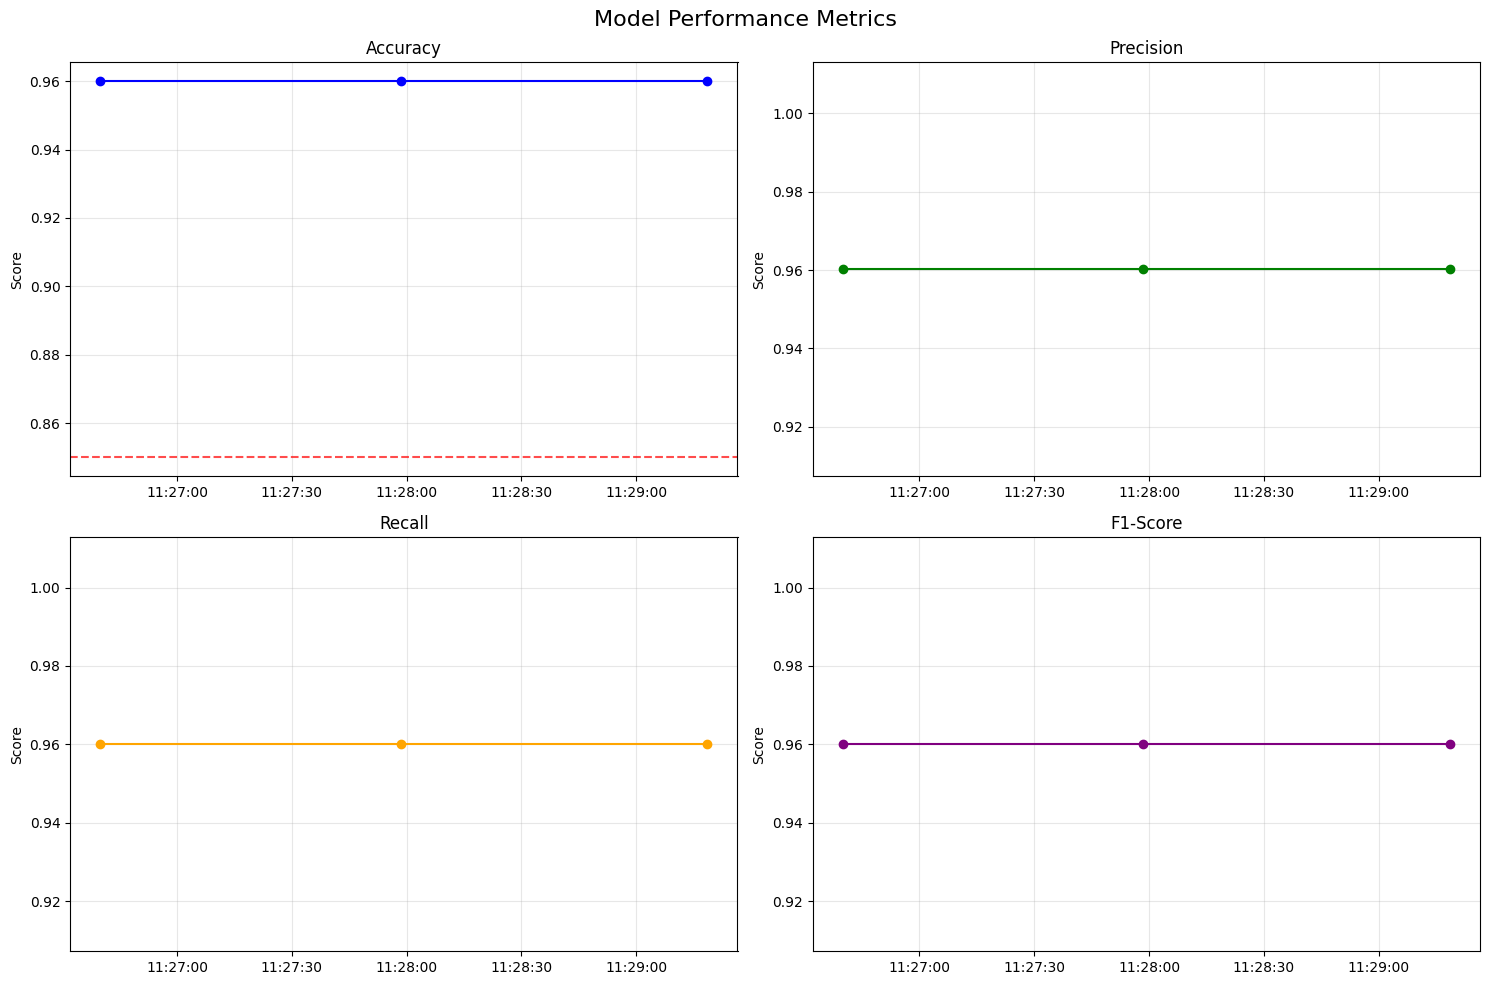

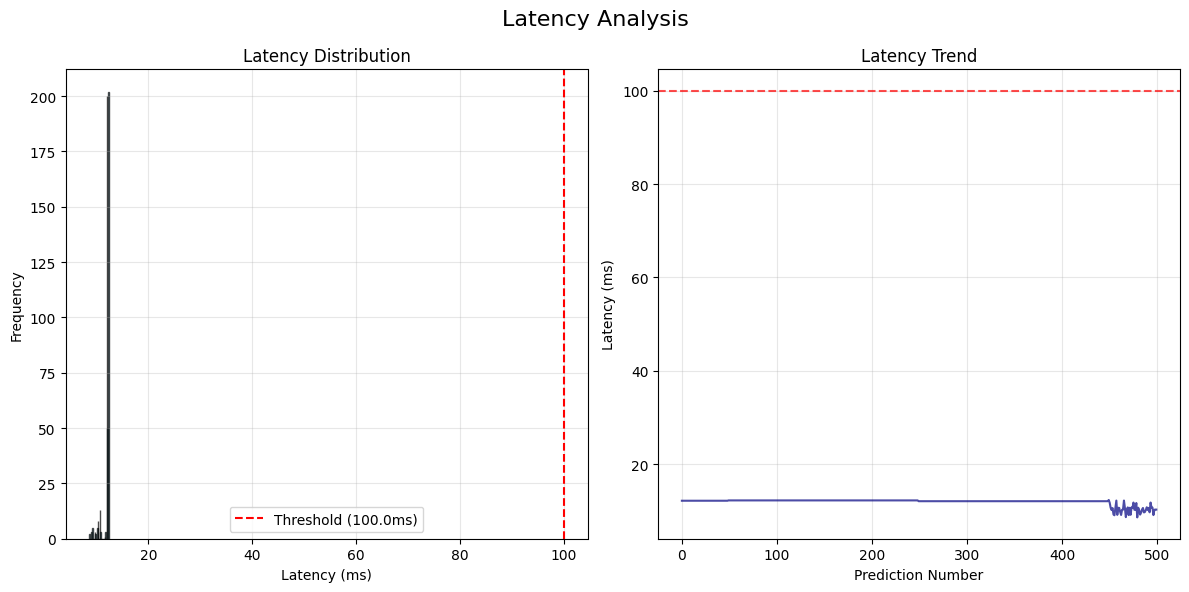

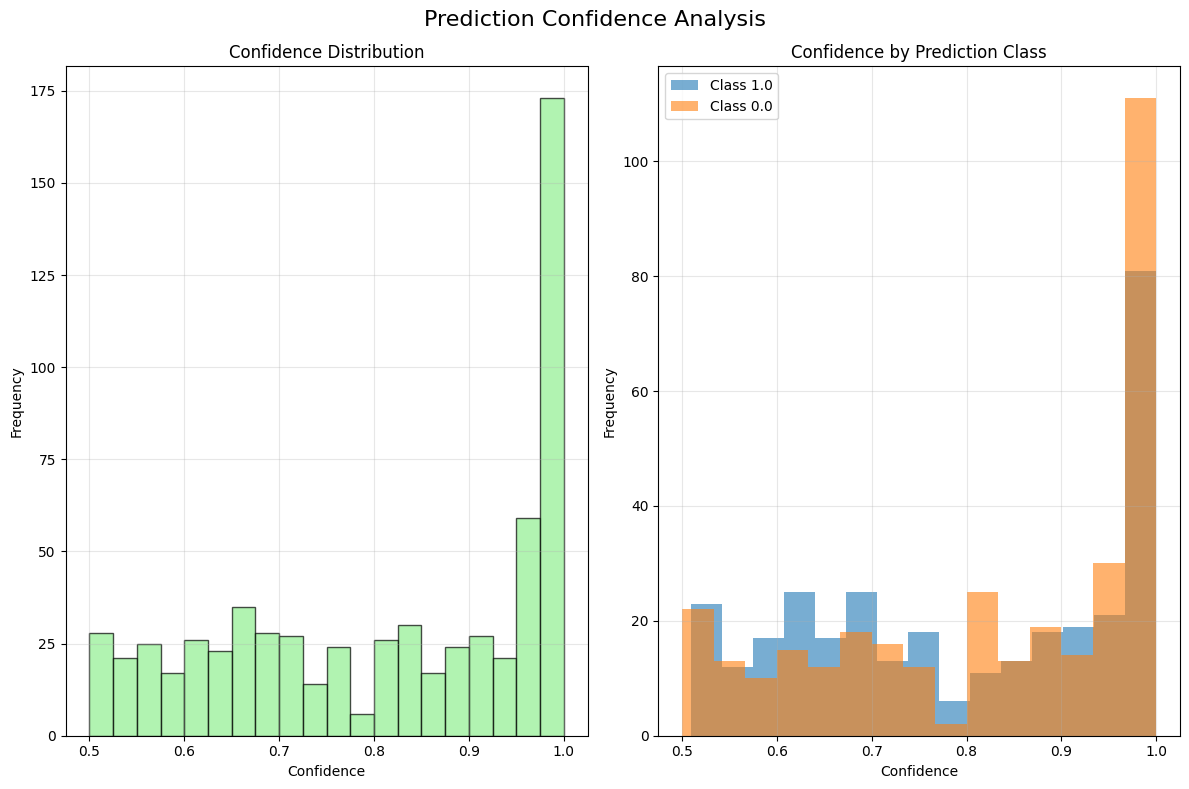


9️⃣ Generating final report...
ML MONITORING REPORT
Generated at: 2025-06-11 11:29:23

📊 GENERAL METRICS:
  • Total predictions: 651
  • Average confidence: 0.619
  • Average latency: 10.31ms
  • Prediction rate: 1.00/window

🚀 DEPLOYMENT STATUS:
  • Current model: 1.0.0
  • Environment: production
  • Status: healthy

🚨 ALERTS (2 active):
  • PERFORMANCE: Low accuracy: 0.700 < 0.85
  • LATENCY: High latency: 150.00ms > 100.0ms

📈 RECENT PERFORMANCE:
  • Accuracy: 0.960
  • Precision: 0.960
  • Recall: 0.960
  • F1-Score: 0.960

💡 RECOMMENDATIONS:
  • Investigate low prediction confidence

🔟 Stopping monitoring...


--- Logging error ---
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f6a8' in position 47: character maps to <undefined>
Call stack:
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "C:\ProgramData\anaconda3\envs\airline-satisfaction\lib\threading.py", line 

✅ Monitoring stopped

🎉 COMPLETE PIPELINE EXECUTED SUCCESSFULLY!


In [13]:
def run_complete_pipeline():
    """Execute complete pipeline demonstration"""
    
    print("🚀 STARTING COMPLETE ML DEPLOYMENT & MONITORING PIPELINE")
    print("="*70)
    
    # 1. Generate sample data
    print("\n1️⃣ Generating training data...")
    X, y = make_classification(
        n_samples=1000,
        n_features=10,
        n_informative=8,
        n_redundant=2,
        n_clusters_per_class=1,
        random_state=42
    )
    print(f"✅ Data generated: {X.shape[0]} samples, {X.shape[1]} features")
    
    # 2. Train model
    print("\n2️⃣ Training model...")
    model = MLModel(model_config)
    training_metrics = model.train(X, y)
    print(f"✅ Model trained with accuracy: {training_metrics['accuracy']:.3f}")
    
    # 3. Deploy model
    print("\n3️⃣ Deploying model...")
    # Use a portion of the original data for validation (guaranteed same distribution)
    X_val, X_discard, y_val, y_discard = train_test_split(
        X, y, test_size=0.8, random_state=123
    )
    deployment_record = deployment_pipeline.deploy_model(
        model, 
        validation_data=(X_val, y_val)
    )
    print(f"✅ Model deployed: version {deployment_record['version']}")
    
    # 4. Start monitoring
    print("\n4️⃣ Starting real-time monitoring...")
    real_time_monitor.start_monitoring(interval=5)  # 5 seconds for demo
    print("✅ Monitoring active")
    
    # 5. Simulate production predictions
    print("\n5️⃣ Simulating production predictions...")
    for i in range(50):
        # Generate test data
        test_sample = np.random.random((1, 10))
        
        # Add occasional noise to simulate drift
        if i > 30 and np.random.random() > 0.7:
            test_sample += np.random.normal(0, 0.5, test_sample.shape)
        
        # Make prediction
        pred, prob, latency = deployment_pipeline.current_model.predict(test_sample)
        
        # Simulate high latency occasionally
        if np.random.random() > 0.9:
            time.sleep(0.2)  # Simulate high latency
        
        if i % 10 == 0:
            print(f"  Prediction {i+1}: {pred[0]}, confidence: {np.max(prob[0]):.3f}")
    
    print("✅ 50 predictions simulated")
    
    # 6. Check status
    print("\n6️⃣ Checking system status...")
    monitoring_status = real_time_monitor.get_monitoring_status()
    print(f"✅ Status: {monitoring_status}")
    
    # 7. Generate alerts (simulation)
    print("\n7️⃣ Testing alert system...")
    
    # Simulate performance alert
    low_performance_metrics = {'accuracy': 0.7, 'precision': 0.65, 'recall': 0.6, 'f1': 0.6}
    perf_alert = alert_system.check_performance_alert(low_performance_metrics)
    if perf_alert:
        alert_system.send_alert(perf_alert)
    
    # Simulate latency alert
    latency_alert = alert_system.check_latency_alert(150.0)
    if latency_alert:
        alert_system.send_alert(latency_alert)
    
    print("✅ Alerts tested")
    
    # 8. Show dashboard
    print("\n8️⃣ Generating visualizations...")
    try:
        dashboard.plot_performance_metrics()
        dashboard.plot_latency_distribution()
        dashboard.plot_prediction_confidence()
    except Exception as e:
        print(f"Visualization error: {e}")
    
    # 9. Final report
    print("\n9️⃣ Generating final report...")
    dashboard.generate_report()
    
    # 10. Stop monitoring
    print("\n🔟 Stopping monitoring...")
    time.sleep(2)  # Wait a bit
    real_time_monitor.stop_monitoring()
    print("✅ Monitoring stopped")
    
    print("\n🎉 COMPLETE PIPELINE EXECUTED SUCCESSFULLY!")
    print("="*70)

# Execute complete pipeline
run_complete_pipeline()

# 9. Additional Utilities

In [14]:
def quick_deploy_new_version():
    """Quick deploy of new version"""
    
    print("🔄 Deploying new version...")
    
    # Configuration for new version
    new_config = ModelConfig(version="1.1.0", n_estimators=150)
    new_model = MLModel(new_config)
    
    # Train with different data
    X_new, y_new = make_classification(n_samples=1200, n_features=10, random_state=999)
    new_model.train(X_new, y_new)
    
    # Deploy
    deployment_record = deployment_pipeline.deploy_model(new_model)
    print(f"✅ New version {deployment_record['version']} deployed!")
    
    return deployment_record

def simulate_rollback():
    """Simulate rollback to previous version"""
    
    print("⏪ Simulating rollback...")
    
    if len(deployment_pipeline.model_registry) < 2:
        print("❌ Need at least 2 versions for rollback")
        return
    
    # Get previous version
    versions = list(deployment_pipeline.model_registry.keys())
    target_version = versions[-2]  # Second to last version
    
    rollback_record = deployment_pipeline.rollback(target_version)
    print(f"✅ Rollback to version {rollback_record['target_version']} completed!")
    
    return rollback_record

def export_metrics_to_csv():
    """Export metrics to CSV"""
    
    # Predictions
    if metrics_collector.predictions_log:
        predictions_df = pd.DataFrame([
            {
                'timestamp': p['timestamp'],
                'prediction': p['prediction'],
                'confidence': p['confidence'],
                'latency': p['latency'],
                'model_version': p['model_version']
            }
            for p in metrics_collector.predictions_log
        ])
        predictions_df.to_csv('predictions_log.csv', index=False)
        print("✅ Predictions exported to predictions_log.csv")
    
    # Performance
    if metrics_collector.performance_metrics:
        performance_df = pd.DataFrame([
            {
                'timestamp': p['timestamp'],
                'model_version': p['model_version'],
                **p['metrics']
            }
            for p in metrics_collector.performance_metrics
        ])
        performance_df.to_csv('performance_metrics.csv', index=False)
        print("✅ Performance metrics exported to performance_metrics.csv")

def cleanup_old_models():
    """Clean up old models keeping only the most recent ones"""
    
    print("🧹 Cleaning up old models...")
    
    models_to_keep = deployment_config.backup_models
    if len(deployment_pipeline.model_registry) <= models_to_keep:
        print(f"✅ Only {len(deployment_pipeline.model_registry)} models. Nothing to clean.")
        return
    
    # Sort by deployment date
    sorted_models = sorted(
        deployment_pipeline.model_registry.items(),
        key=lambda x: x[1]['deployed_at'],
        reverse=True
    )
    
    # Keep only the most recent ones
    for version, info in sorted_models[models_to_keep:]:
        try:
            Path(info['path']).unlink()  # Delete file
            del deployment_pipeline.model_registry[version]
            print(f"  🗑️ Model {version} removed")
        except Exception as e:
            print(f"  ❌ Error removing {version}: {e}")
    
    print(f"✅ Cleanup completed. {len(deployment_pipeline.model_registry)} models kept.")

# Utility functions
def show_model_registry():
    """Show model registry"""
    
    print("\n📋 MODEL REGISTRY:")
    print("-" * 50)
    
    if not deployment_pipeline.model_registry:
        print("No models in registry")
        return
    
    for version, info in deployment_pipeline.model_registry.items():
        status = "🟢 ACTIVE" if deployment_pipeline.current_model and \
                deployment_pipeline.current_model.config.version == version else "⚫ INACTIVE"
        print(f"{status} {version}")
        print(f"  📅 Deployed: {info['deployed_at'].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  📁 Path: {info['path']}")
        print()

def show_alert_history():
    """Show alert history"""
    
    print("\n🚨 ALERT HISTORY:")
    print("-" * 50)
    
    if not alert_system.alert_history:
        print("No alerts in history")
        return
    
    for alert in list(alert_system.alert_history)[-10:]:  # Last 10
        severity_icon = {"LOW": "🟡", "MEDIUM": "🟠", "HIGH": "🔴", "CRITICAL": "⚡"}
        icon = severity_icon.get(alert['severity'], "❓")
        
        print(f"{icon} [{alert['timestamp'].strftime('%H:%M:%S')}] {alert['type']}")
        print(f"   {alert['message']}")
        print()

# Example commands
print("\n" + "="*60)
print("AVAILABLE COMMANDS:")
print("="*60)
print("• quick_deploy_new_version() - Deploy new version")
print("• simulate_rollback() - Rollback to previous version")
print("• export_metrics_to_csv() - Export metrics")
print("• cleanup_old_models() - Clean up old models")
print("• show_model_registry() - View registered models")
print("• show_alert_history() - View alert history")
print("• dashboard.create_interactive_dashboard() - Interactive dashboard")
print("• deployment_pipeline.health_check() - Check health")
print("="*60)

print("\n🎊 ML DEPLOYMENT & MONITORING PIPELINE READY FOR USE!")
print("Execute the commands above to test different functionalities.")


AVAILABLE COMMANDS:
• quick_deploy_new_version() - Deploy new version
• simulate_rollback() - Rollback to previous version
• export_metrics_to_csv() - Export metrics
• cleanup_old_models() - Clean up old models
• show_model_registry() - View registered models
• show_alert_history() - View alert history
• dashboard.create_interactive_dashboard() - Interactive dashboard
• deployment_pipeline.health_check() - Check health

🎊 ML DEPLOYMENT & MONITORING PIPELINE READY FOR USE!
Execute the commands above to test different functionalities.
